# 02 — Arm 1: TF-IDF / k-NN Retrieval

Dataset C, AMLH coursework. Validation-only hyperparameter, preprocessing, index-variant,
indexing-scheme, split-design, and baseline-model experiments for the traditional NLP arm. No
test-set cell anywhere in this notebook. All logic lives in `src/amlh`; this notebook only calls
it, displays results, and persists tables to `artefacts/` and figures to `figures/`.

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from amlh import arm1_experiments as ae
from amlh import arm1_tfidf, evaluate, features
from amlh.config import ARTEFACTS_DIR, FIGURES_DIR, HYPERPARAMETERS, SEED, set_seed
from amlh.data import load_train, make_hard_validation_split, make_random_split

## 1. Load splits from `artefacts/`

In [2]:
set_seed()

fit = pd.read_csv(ARTEFACTS_DIR / "split_fit.csv")
val = pd.read_csv(ARTEFACTS_DIR / "split_val.csv")
print(f"fit={len(fit)} ({fit.disease.nunique()} classes) | val={len(val)} ({val.disease.nunique()} classes)")

fit=8691 (906 classes) | val=200 (102 classes)


## 2. Hyperparameter grid — class-blob index, variant Q

`ngram_range × sublinear_tf × min_df × stop_words × k` — 80 configs. Selection uses a
one-standard-error rule (`ae.select_within_one_se`), not the raw argmax: with n=200 validation
items, SE ≈ 3.5pp at the top accuracy, so among configs within 1 SE of the best we take the
simplest (lowest k, unigrams, no stop-word removal). `k`'s effect is limited under blob indexing
since each class contributes exactly one row to the index regardless of `k` — reported anyway,
as evidence for §4.2.

In [3]:
grid_Q = ae.run_vectoriser_grid(
    fit, val, "Q",
    ngram_ranges=[(1, 1), (1, 2)],
    sublinear_tf_opts=[False, True],
    min_dfs=[1, 2],
    stop_words_opts=[None, "english"],
    ks=[1, 3, 5, 10, 20],
)
grid_Q.to_csv(ARTEFACTS_DIR / "arm1_grid_Q.csv", index=False)
print(f"{len(grid_Q)} configs run")
grid_Q.sort_values("accuracy", ascending=False).head(10)

80 configs run


,ngram_range,sublinear_tf,min_df,stop_words,k,accuracy,acc_at_5,macro_f1,mrr
47,"(1, 2)",False,1,english,5,0.835,0.905,0.710753,0.859333
49,"(1, 2)",False,1,english,20,0.835,0.905,0.710753,0.862472
46,"(1, 2)",False,1,english,3,0.835,0.890,0.710753,0.855833
48,"(1, 2)",False,1,english,10,0.835,0.905,0.710753,0.862056
45,"(1, 2)",False,1,english,1,0.835,0.835,0.710753,0.835000
26,"(1, 1)",True,1,english,3,0.825,0.905,0.684252,0.860833
25,"(1, 1)",True,1,english,1,0.825,0.825,0.684252,0.825000
68,"(1, 2)",True,1,english,10,0.825,0.910,0.683202,0.864500
67,"(1, 2)",True,1,english,5,0.825,0.910,0.683202,0.862833
66,"(1, 2)",True,1,english,3,0.825,0.900,0.683202,0.860833


In [4]:
argmax_row_Q = grid_Q.loc[grid_Q["accuracy"].idxmax()]
selected_row_Q = ae.select_within_one_se(grid_Q, n_val=len(val))
print("argmax row:")
print(argmax_row_Q)
print()
print("selected (simplest within 1 SE) row:")
print(selected_row_Q)

best_vec_kwargs = {
    "ngram_range": selected_row_Q["ngram_range"],
    "sublinear_tf": selected_row_Q["sublinear_tf"],
    "min_df": selected_row_Q["min_df"],
    "stop_words": selected_row_Q["stop_words"],
}
best_k = int(selected_row_Q["k"])
print()
print("best_vec_kwargs (Q, from step 2):", best_vec_kwargs)
print("best_k (Q, from step 2):", best_k)

argmax row:
ngram_range       (1, 2)
sublinear_tf       False
min_df                 1
stop_words       english
k                      1
accuracy           0.835
acc_at_5           0.835
macro_f1        0.710753
mrr                0.835
Name: 45, dtype: object

selected (simplest within 1 SE) row:
ngram_range       (1, 1)
sublinear_tf       False
min_df                 1
stop_words          None
k                      1
accuracy            0.82
acc_at_5            0.82
macro_f1        0.672868
mrr                 0.82
Name: 0, dtype: object

best_vec_kwargs (Q, from step 2): {'ngram_range': (1, 1), 'sublinear_tf': np.False_, 'min_df': np.int64(1), 'stop_words': None}
best_k (Q, from step 2): 1


## 3. Preprocessing ablation at the best grid config

`raw` / `lemma_stop` (spaCy lemmatisation + stop-word removal) / `lemma_only` (lemmatisation, stop
words kept), at variant Q and the selected vectoriser config/`k` from step 2.

In [5]:
preprocessing_ablation = ae.run_preprocessing_ablation(fit, val, best_vec_kwargs, best_k)
preprocessing_ablation.to_csv(ARTEFACTS_DIR / "arm1_preprocessing_ablation.csv", index=False)
preprocessing_ablation

,preprocessing,accuracy,acc_at_5,macro_f1,mrr
0,raw,0.820,0.820,0.672868,0.820
1,lemma_stop,0.805,0.805,0.650000,0.805
2,lemma_only,0.825,0.825,0.678036,0.825


In [6]:
# Same within-1-SE-prefer-simplest rule as the vectoriser grid: don't pick lemmatisation
# on a margin the 200-item hold-out can't actually resolve.
best_acc_ablation = preprocessing_ablation["accuracy"].max()
se_ablation = (best_acc_ablation * (1 - best_acc_ablation) / len(val)) ** 0.5
raw_acc = preprocessing_ablation.loc[preprocessing_ablation["preprocessing"] == "raw", "accuracy"].item()

if raw_acc >= best_acc_ablation - se_ablation:
    best_preprocessing = "raw"
else:
    best_preprocessing = preprocessing_ablation.loc[preprocessing_ablation["accuracy"].idxmax(), "preprocessing"]

print(f"best accuracy: {best_acc_ablation:.3f} (SE={se_ablation:.3f}) | raw accuracy: {raw_acc:.3f}")
print("selected preprocessing (prefer raw within 1 SE):", best_preprocessing)

best accuracy: 0.825 (SE=0.027) | raw accuracy: 0.820
selected preprocessing (prefer raw within 1 SE): raw


## 4. Index variants Q / QL / QLA / QLAD

`QLAD` needs the NHS class documents — confirm full coverage over the fit split's disease
universe before using it.

In [7]:
coverage = features.doc_coverage(fit["disease"].unique())
print(json.dumps(coverage, indent=2))
assert coverage["n_found"] == coverage["n_total"] == 906, "expected full 906/906 NHS doc coverage"


{
  "n_total": 906,
  "n_found": 906,
  "missing": []
}


In [8]:
index_variants = ae.run_index_variant_comparison(
    fit, val, ["Q", "QL", "QLA", "QLAD"], best_vec_kwargs, best_k
)
index_variants.to_csv(ARTEFACTS_DIR / "arm1_index_variants.csv", index=False)
index_variants

,variant,accuracy,acc_at_5,macro_f1,mrr
0,Q,0.82,0.82,0.672868,0.82
1,QL,0.82,0.82,0.670256,0.82
2,QLA,0.82,0.82,0.672917,0.82
3,QLAD,0.82,0.82,0.683069,0.82


### 4a. Shift-aware ("hard") hold-out — evidence for the pre-registered tie-break

The standard hold-out is drawn from the same one-pass generation as the fit split, so a held-out
question is a phrasing sibling of those left in training (cosine 0.572) while a test question is
not (0.391) — see §3.1. The shift-aware hold-out is a class-aware sample drawn **only from the
training rows whose question shares no substantive word with its own disease label**, so it
approximates the lexeme-absent stratum the test set resembles. It is constructed from training
data alone; no test-side text or label is read here.

Its role is narrow and pre-registered in `CLAUDE.md`: it breaks ties the standard hold-out cannot
resolve. Where the standard hold-out discriminates, the standard hold-out decides.


In [9]:
hard_split = make_hard_validation_split(load_train(), seed=SEED)
print(
    f"hard fit={len(hard_split.fit)} | hard val={len(hard_split.val)} "
    f"({hard_split.val.disease.nunique()} classes)"
)

index_variants_hard = ae.run_index_variant_comparison(
    hard_split.fit, hard_split.val, ["Q", "QL", "QLA", "QLAD"], best_vec_kwargs, best_k
)
index_variants_hard.to_csv(ARTEFACTS_DIR / "arm1_index_variants_hardval.csv", index=False)
index_variants_hard

hard fit=8491 | hard val=400 (400 classes)


,variant,accuracy,acc_at_5,macro_f1,mrr
0,Q,0.1800,0.1800,0.122403,0.1800
1,QL,0.1725,0.1725,0.118553,0.1725
2,QLA,0.2625,0.2625,0.187019,0.2625
3,QLAD,0.3275,0.3275,0.230929,0.3275


In [10]:
# Pre-registered selection rule (CLAUDE.md hard rule #2). The standard hold-out gets first
# say; only where it fails to discriminate — a within-1-SE tie at n=200 — does the shift-aware
# hold-out break the tie, on the §3.1 grounds that the test distribution resembles the
# lexeme-absent stratum rather than the lexeme-present majority the standard split is drawn from.
std_best = index_variants["accuracy"].max()
std_se = (std_best * (1 - std_best) / len(val)) ** 0.5
std_tied = index_variants.loc[index_variants["accuracy"] >= std_best - std_se, "variant"].tolist()

if len(std_tied) == 1:
    best_variant = std_tied[0]
    selection_basis = "standard hold-out (discriminates without a tie-break)"
else:
    contenders = index_variants_hard[index_variants_hard["variant"].isin(std_tied)]
    best_variant = contenders.loc[contenders["accuracy"].idxmax(), "variant"]
    hard_se = (contenders["accuracy"].max() * (1 - contenders["accuracy"].max()) / len(hard_split.val)) ** 0.5
    runner_up = contenders["accuracy"].nlargest(2).iloc[-1]
    selection_basis = (
        f"shift-aware tie-break over {std_tied}; margin over runner-up "
        f"{contenders['accuracy'].max() - runner_up:.3f} vs SE {hard_se:.3f}"
    )

print(f"standard-val accuracies: {dict(zip(index_variants['variant'], index_variants['accuracy']))}")
print(f"within-1-SE set at {std_best:.3f} +/- {std_se:.3f}: {std_tied}")
print(f"hard-val accuracies:     {dict(zip(index_variants_hard['variant'], index_variants_hard['accuracy']))}")
print(f"selected index variant:  {best_variant}  [{selection_basis}]")

standard-val accuracies: {'Q': 0.82, 'QL': 0.82, 'QLA': 0.82, 'QLAD': 0.82}
within-1-SE set at 0.820 +/- 0.027: ['Q', 'QL', 'QLA', 'QLAD']
hard-val accuracies:     {'Q': 0.18, 'QL': 0.1725, 'QLA': 0.2625, 'QLAD': 0.3275}
selected index variant:  QLAD  [shift-aware tie-break over ['Q', 'QL', 'QLA', 'QLAD']; margin over runner-up 0.065 vs SE 0.023]


### 4b. Variant-specific vectoriser re-check

Blob length differs enormously by variant (short questions vs long NHS prose), so the step-2
optimum — tuned on variant Q only — may not transfer to `best_variant`. Re-run the vectoriser
grid restricted to `best_variant` and re-select within 1 SE; if the winner differs from step 2,
use the variant-specific winner for everything downstream.

In [11]:
grid_variant = ae.run_vectoriser_grid(
    fit, val, best_variant,
    ngram_ranges=[(1, 1), (1, 2)],
    sublinear_tf_opts=[False, True],
    min_dfs=[1, 2],
    stop_words_opts=[None, "english"],
    ks=[1, 3, 5, 10, 20],
)
grid_variant.to_csv(ARTEFACTS_DIR / f"arm1_grid_{best_variant}.csv", index=False)
selected_row_variant = ae.select_within_one_se(grid_variant, n_val=len(val))
print(selected_row_variant)

ngram_range       (1, 2)
sublinear_tf       False
min_df                 1
stop_words          None
k                      1
accuracy            0.85
acc_at_5            0.85
macro_f1        0.725137
mrr                 0.85
Name: 40, dtype: object


In [12]:
variant_vec_kwargs = {
    "ngram_range": selected_row_variant["ngram_range"],
    "sublinear_tf": selected_row_variant["sublinear_tf"],
    "min_df": selected_row_variant["min_df"],
    "stop_words": selected_row_variant["stop_words"],
}
variant_k = int(selected_row_variant["k"])

config_unchanged = variant_vec_kwargs == best_vec_kwargs and variant_k == best_k
print("variant-specific config matches step-2 config:", config_unchanged)

if not config_unchanged:
    print("Using the variant-specific winner downstream (discrepancy noted for §2.5).")
    best_vec_kwargs = variant_vec_kwargs
    best_k = variant_k

print("final best_vec_kwargs:", best_vec_kwargs)
print("final best_k:", best_k)

variant-specific config matches step-2 config: False
Using the variant-specific winner downstream (discrepancy noted for §2.5).
final best_vec_kwargs: {'ngram_range': (1, 2), 'sublinear_tf': np.False_, 'min_df': np.int64(1), 'stop_words': None}
final best_k: 1


## 5. Indexing scheme — class-blob vs additive-per-row

A designed comparison for §4.2, not a footnote: does spreading the index over one row per
training example (rather than one blob per class) change retrieval accuracy at the winning
variant and vectoriser config?

In [13]:
indexing_scheme = ae.run_indexing_scheme_comparison(fit, val, best_variant, best_vec_kwargs, best_k)
indexing_scheme.to_csv(ARTEFACTS_DIR / "arm1_indexing_scheme.csv", index=False)
indexing_scheme

,scheme,n_index_rows,accuracy,acc_at_5,macro_f1,mrr
0,class_blob,906,0.85,0.85,0.725137,0.85
1,additive_per_row,9597,0.73,0.73,0.539726,0.73


In [14]:
indexing_scheme_hard = ae.run_indexing_scheme_comparison(
    hard_split.fit, hard_split.val, best_variant, best_vec_kwargs, best_k
)
indexing_scheme_hard.to_csv(ARTEFACTS_DIR / "arm1_indexing_scheme_hardval.csv", index=False)
indexing_scheme_hard

,scheme,n_index_rows,accuracy,acc_at_5,macro_f1,mrr
0,class_blob,906,0.3975,0.3975,0.296304,0.3975
1,additive_per_row,9397,0.3250,0.3250,0.231059,0.3250


In [15]:
# The tie-break is a tie-break, not an override: it applies only where the standard hold-out
# cannot discriminate. Here the standard hold-out separates the two schemes by far more than its
# own SE, and the shift-aware hold-out — which ranks them the other way — does *not* separate
# them at better than one SE. A protocol that cannot resolve a comparison cannot overturn one
# that can, so the standard hold-out's pick stands. Scheme selection is recorded in §4.2 as an
# open weakness rather than a settled result.
std_scheme_best = indexing_scheme["accuracy"].max()
std_scheme_se = (std_scheme_best * (1 - std_scheme_best) / len(val)) ** 0.5
std_scheme_margin = std_scheme_best - indexing_scheme["accuracy"].nlargest(2).iloc[-1]

hard_scheme_best = indexing_scheme_hard["accuracy"].max()
hard_scheme_se = (hard_scheme_best * (1 - hard_scheme_best) / len(hard_split.val)) ** 0.5
hard_scheme_margin = hard_scheme_best - indexing_scheme_hard["accuracy"].nlargest(2).iloc[-1]

std_pick = indexing_scheme.loc[indexing_scheme["accuracy"].idxmax(), "scheme"]
hard_pick = indexing_scheme_hard.loc[indexing_scheme_hard["accuracy"].idxmax(), "scheme"]

print(f"standard-val: {std_pick} by {std_scheme_margin:.3f} (SE {std_scheme_se:.3f}) "
      f"-> {'decisive' if std_scheme_margin > std_scheme_se else 'not decisive'}")
print(f"hard-val:     {hard_pick} by {hard_scheme_margin:.3f} (SE {hard_scheme_se:.3f}) "
      f"-> {'decisive' if hard_scheme_margin > hard_scheme_se else 'not decisive'}")

if hard_pick != std_pick and hard_scheme_margin > hard_scheme_se and std_scheme_margin <= std_scheme_se:
    best_scheme = hard_pick
    scheme_basis = "shift-aware hold-out (standard hold-out did not discriminate)"
else:
    best_scheme = std_pick
    scheme_basis = "standard hold-out (shift-aware hold-out does not overturn it at >1 SE)"

print(f"selected indexing scheme: {best_scheme}  [{scheme_basis}]")

standard-val: class_blob by 0.120 (SE 0.025) -> decisive
hard-val:     class_blob by 0.073 (SE 0.024) -> decisive
selected indexing scheme: class_blob  [standard hold-out (shift-aware hold-out does not overturn it at >1 SE)]


## 6. Split-robustness check — stratified vs unstratified

Rerun the top-3 variant-Q grid configs (step 2) under an unstratified `make_random_split`
(NLP1/NLP3 pattern), across 3 random seeds, and check whether the config ranking survives a
different split design. **Absolute accuracy is not comparable across split designs** — fit/val
composition differs — only whether the *ranking* of the three configs is preserved is the thing
under test here.

In [16]:
top3_configs = (
    grid_Q.sort_values("accuracy", ascending=False)
    .head(3)[["ngram_range", "sublinear_tf", "min_df", "stop_words", "k"]]
    .to_dict("records")
)
for i, cfg in enumerate(top3_configs, start=1):
    print(i, cfg)

train_full = load_train()
split_robustness = ae.run_split_robustness(train_full, top3_configs, variant="Q", seeds=(42, 43, 44))
split_robustness.to_csv(ARTEFACTS_DIR / "arm1_split_robustness.csv", index=False)
split_robustness

1 {'ngram_range': (1, 2), 'sublinear_tf': False, 'min_df': 1, 'stop_words': 'english', 'k': 5}
2 {'ngram_range': (1, 2), 'sublinear_tf': False, 'min_df': 1, 'stop_words': 'english', 'k': 20}
3 {'ngram_range': (1, 2), 'sublinear_tf': False, 'min_df': 1, 'stop_words': 'english', 'k': 3}


,config_rank,seed,ngram_range,sublinear_tf,min_df,stop_words,k,accuracy,acc_at_5,macro_f1,mrr
0,1,42,"(1, 2)",False,1,english,5,0.800,0.895,0.709195,0.838500
1,2,42,"(1, 2)",False,1,english,20,0.800,0.900,0.709195,0.843200
2,3,42,"(1, 2)",False,1,english,3,0.800,0.880,0.709195,0.835000
3,1,43,"(1, 2)",False,1,english,5,0.790,0.895,0.658610,0.830833
4,2,43,"(1, 2)",False,1,english,20,0.790,0.895,0.658610,0.834185
5,3,43,"(1, 2)",False,1,english,3,0.790,0.855,0.658610,0.820833
6,1,44,"(1, 2)",False,1,english,5,0.785,0.890,0.693651,0.826750
7,2,44,"(1, 2)",False,1,english,20,0.785,0.890,0.693651,0.829869
8,3,44,"(1, 2)",False,1,english,3,0.785,0.860,0.693552,0.820000


In [17]:
stratified_ranking = (
    grid_Q.sort_values("accuracy", ascending=False).head(3)["accuracy"].reset_index(drop=True)
)
mean_by_rank = split_robustness.groupby("config_rank")["accuracy"].mean()
print("stratified-split accuracy, top 3 configs (rank order):")
print(stratified_ranking.to_string())
print()
print("mean unstratified-split accuracy across 3 seeds, by config_rank:")
print(mean_by_rank.to_string())
print()
ranking_preserved = list(mean_by_rank.sort_values(ascending=False).index) == list(mean_by_rank.index)
print("config ranking order preserved under the random split (by mean accuracy):", ranking_preserved)

stratified-split accuracy, top 3 configs (rank order):
0    0.835
1    0.835
2    0.835

mean unstratified-split accuracy across 3 seeds, by config_rank:
config_rank
1    0.791667
2    0.791667
3    0.791667

config ranking order preserved under the random split (by mean accuracy): True


## 7. Supervised baselines — LinearSVC / LogisticRegression / RandomForest

Per-row (not blob) TF-IDF classification at the best vectoriser config, contrasting learned
decision boundaries against neighbour matching under ~10 examples per class. The RandomForest
baseline follows the course pattern in `NLP1_word_semantics_solution.ipynb`, which evaluates a
`RandomForestClassifier` over TF-IDF features via `classification_report`.

In [18]:
supervised_baselines = ae.run_supervised_baselines(fit, val, best_vec_kwargs)
supervised_baselines.to_csv(ARTEFACTS_DIR / "arm1_supervised_baselines.csv", index=False)
supervised_baselines

,model,accuracy,acc_at_5,macro_f1,mrr
0,svc,0.815,0.905,0.671391,0.860792
1,logreg,0.635,0.785,0.516049,0.700486
2,random_forest,0.765,0.910,0.598010,0.826881


## 8. Accuracy–coverage curve

Under similarity thresholding on the best overall k-NN configuration (best variant / vectoriser
config / k / indexing scheme): as the abstention threshold rises, coverage falls and the accuracy
of the remaining, retained predictions should rise. Relevant to the healthcare discussion of
abstention as a safety mechanism (§4.3).

In [19]:
if best_scheme == "class_blob":
    index_texts, index_labels = features.build_index(fit, best_variant)
else:
    index_texts, index_labels = features.build_index_additive(fit, best_variant)

ranked, top_sim = arm1_tfidf.knn_rank(
    index_texts, index_labels, val["question"].tolist(), best_k, best_vec_kwargs
)
gold = val["disease"].tolist()

thresholds = [round(0.05 * i, 2) for i in range(21)]  # 0.00 .. 1.00
coverage_curve = evaluate.accuracy_coverage_curve(ranked, gold, top_sim, thresholds)
coverage_curve.to_csv(ARTEFACTS_DIR / "arm1_coverage_curve.csv", index=False)
coverage_curve

,threshold,coverage,n_covered,accuracy
0,0.00,1.000,200,0.850000
1,0.05,1.000,200,0.850000
2,0.10,0.970,194,0.855670
3,0.15,0.925,185,0.870270
4,0.20,0.870,174,0.873563
5,0.25,0.810,162,0.882716
6,0.30,0.660,132,0.886364
7,0.35,0.565,113,0.902655
8,0.40,0.365,73,0.945205
9,0.45,0.275,55,0.963636


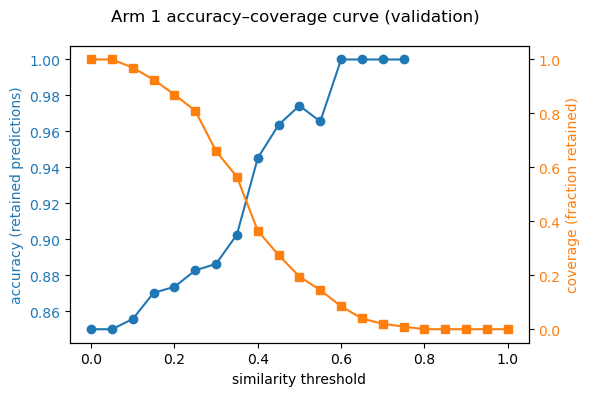

In [20]:
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(coverage_curve["threshold"], coverage_curve["accuracy"], marker="o", color="tab:blue", label="accuracy")
ax1.set_xlabel("similarity threshold")
ax1.set_ylabel("accuracy (retained predictions)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(coverage_curve["threshold"], coverage_curve["coverage"], marker="s", color="tab:orange", label="coverage")
ax2.set_ylabel("coverage (fraction retained)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

fig.suptitle("Arm 1 accuracy–coverage curve (validation)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig4_coverage_curve.png", dpi=150)
plt.show()

## 9. Freeze Arm 1 hyperparameters into `config.py`

Values assembled from the DataFrames computed above — printed here, then copied into
`src/amlh/config.py`'s `HYPERPARAMETERS` Arm 1 fields as a follow-up source edit (not hand-typed
numbers). These fields describe the winning k-NN pipeline only — the LinearSVC/LogReg/RandomForest
and additive-per-row results above are comparison points for the report, not carried forward
into Arm 3's shortlist.

In [21]:
frozen_arm1_hyperparameters = {
    "ngram_range": tuple(int(x) for x in best_vec_kwargs["ngram_range"]),
    "min_df": int(best_vec_kwargs["min_df"]),
    "max_df": 1.0,
    "sublinear_tf": bool(best_vec_kwargs["sublinear_tf"]),
    "stop_words": best_vec_kwargs["stop_words"],
    "lemmatise": best_preprocessing != "raw",
    "index_variant": str(best_variant),
    "index_scheme": str(best_scheme),
    "k_neighbors": int(best_k),
}
print(json.dumps({**frozen_arm1_hyperparameters, "ngram_range": list(frozen_arm1_hyperparameters["ngram_range"])}, indent=2))

{
  "ngram_range": [
    1,
    2
  ],
  "min_df": 1,
  "max_df": 1.0,
  "sublinear_tf": false,
  "stop_words": null,
  "lemmatise": false,
  "index_variant": "QLAD",
  "index_scheme": "class_blob",
  "k_neighbors": 1
}


## 10. Ranking depth for cross-arm comparability

At the frozen `k_neighbors=1`, `knn_rank`'s similarity-weighted vote holds exactly one label, so
`ranked` has length 1 for every query — confirmed below from `arm1_grid_QLAD.csv` itself, not
asserted from memory. Two things follow: Arm 1's Top-5/MRR columns are accuracy repeated (not
genuine ranking metrics, unlike Arm 2's), and there is no top-20 shortlist for Arm 3's
"TF-IDF shortlists, LLM selects" design to draw on.

`arm1_tfidf.knn_rank` gets an optional `depth` parameter that appends lower-confidence labels
below its **unchanged** head — the k-neighbour vote that produces every prediction already
frozen in `config.py` is untouched; nothing about `index_variant`, `index_scheme`, `ngram_range`
or `k_neighbors` is revisited here. This section proves that identity over all 200 validation
items (not just spot-checked), then persists per-item predictions and a shortlist-ceiling table
so McNemar against Arm 2 and the §3.3 error analysis have per-item Arm 1 output to read.

Everything below reads `config.HYPERPARAMETERS` — the values frozen in §9 above — not this run's
local `best_*` variables, so it reproduces standalone after a kernel restart with only §1 (load
splits) rerun first, without needing §2–§9's exploratory grids.

In [22]:
grid_qlad = pd.read_csv(ARTEFACTS_DIR / "arm1_grid_QLAD.csv")
k1_rows = grid_qlad[grid_qlad["k"] == 1]
degenerate = bool(
    (k1_rows["accuracy"] == k1_rows["acc_at_5"]).all() and (k1_rows["accuracy"] == k1_rows["mrr"]).all()
)
print(f"{len(k1_rows)} k=1 rows in arm1_grid_QLAD.csv; accuracy == acc_at_5 == mrr for all of them: {degenerate}")
assert degenerate, "expected every k=1 row to have a length-1 ranked list, hence acc==acc@5==mrr"
k1_rows[["ngram_range", "sublinear_tf", "min_df", "stop_words", "accuracy", "acc_at_5", "mrr"]].head()

16 k=1 rows in arm1_grid_QLAD.csv; accuracy == acc_at_5 == mrr for all of them: True


,ngram_range,sublinear_tf,min_df,stop_words,accuracy,acc_at_5,mrr
0,"(1, 1)",False,1,NaN,0.820,0.820,0.820
5,"(1, 1)",False,1,english,0.815,0.815,0.815
10,"(1, 1)",False,2,NaN,0.740,0.740,0.740
15,"(1, 1)",False,2,english,0.740,0.740,0.740
20,"(1, 1)",True,1,NaN,0.825,0.825,0.825


In [23]:
SHORTLIST_DEPTH = 20

ranked_frozen, top_sim_frozen = ae.frozen_ranking(fit, val, HYPERPARAMETERS)
ranked_deep, top_sim_deep = ae.frozen_ranking(fit, val, HYPERPARAMETERS, depth=SHORTLIST_DEPTH)

top1_frozen = [r[0] for r in ranked_frozen]
top1_deep = [r[0] for r in ranked_deep]
n_items = len(val)
n_identical = sum(a == b for a, b in zip(top1_frozen, top1_deep))
print(f"top-1 identical between depth=None and depth={SHORTLIST_DEPTH}: {n_identical}/{n_items} items")

assert top1_frozen == top1_deep, "ranking-depth path changed a frozen top-1 prediction"
assert top_sim_frozen == top_sim_deep, "ranking-depth path changed the reported top similarity"
print("assertion passed: the ranking-depth path changes no frozen top-1 prediction")

top-1 identical between depth=None and depth=20: 200/200 items
assertion passed: the ranking-depth path changes no frozen top-1 prediction


In [24]:
val_predictions = ae.build_val_predictions(fit, val, HYPERPARAMETERS, depth=SHORTLIST_DEPTH)
assert val_predictions["pred"].tolist() == top1_frozen, "persisted predictions disagree with the frozen top-1 check above"

val_predictions.to_csv(ARTEFACTS_DIR / "arm1_val_predictions.csv", index=False)
print(f"{len(val_predictions)} rows written to arm1_val_predictions.csv")
val_predictions.head()

200 rows written to arm1_val_predictions.csv


,question,gold,pred,top_1,top_2,top_3,top_4,top_5,top_6,top_7,...,top_12,top_13,top_14,top_15,top_16,top_17,top_18,top_19,top_20,top_sim
0,"What does the term ""acute"" mean in acute myelo...",acute_myeloid_leukaemia,chronic_myeloid_leukaemia,chronic_myeloid_leukaemia,acute_myeloid_leukaemia,acute_pancreatitis,acute_lymphoblastic_leukaemia,acute_cholecystitis,hairy_cell_leukaemia,acute_kidney_injury,...,developmental_coordination_disorder_dyspraxia,vitamins_and_minerals_vitamin_b,schistosomiasis,chronic_pancreatitis,pregnancy_and_baby_newborn_physical_exam,shortness_of_breath,empyema,gallstones,social_care_and_support_guide_making_decisions...,0.287840
1,What is the cost of nose reshaping in the UK?,cosmetic_procedures_cosmetic_surgery_nose_resh...,cosmetic_procedures_cosmetic_surgery_nose_resh...,cosmetic_procedures_cosmetic_surgery_nose_resh...,cosmetic_procedures_advice_cosmetic_procedures...,social_care_and_support_guide_money_work_and_b...,cosmetic_procedures_cosmetic_surgery_labiaplasty,cosmetic_procedures_cosmetic_surgery_tummy_tuck,cosmetic_procedures_cosmetic_surgery_facelift,cosmetic_procedures_advice_cosmetic_surgery_ab...,...,medicines_information,cosmetic_procedures_non_surgical_cosmetic_proc...,catarrh,nosebleed,cosmetic_procedures_cosmetic_surgery_breast_en...,autosomal_dominant_polycystic_kidney_disease_a...,vasculitis,social_care_and_support_guide_money_work_and_b...,macular_hole,0.483378
2,What should I do if a sharp object has pierced...,eye_injuries,eye_injuries,eye_injuries,red_eye,baby_first_aid_and_safety_first_aid_how_to_sto...,lazy_eye,black_eye,herpes_simplex_eye_infections,double_vision,...,macular_hole,first_aid,short_sightedness,detached_retina_retinal_detachment,pregnancy_and_baby_spotting_signs_serious_illness,long_sightedness,stye,watering_eyes,conjunctivitis,0.200919
3,Will I need a health check before my arthroscopy?,arthroscopy_getting_ready,arthroscopy_getting_ready,arthroscopy_getting_ready,arthroscopy_what_happens_on_the_day,nhs_health_check,colposcopy_getting_ready,having_surgery_specialist,colonoscopy_getting_ready,baby_support_and_services_your_6_week_postnata...,...,pregnancy_and_baby_having_a_baby_that_might_be...,gastroscopy_getting_ready,having_surgery_afterwards,autism_easy_read_and_videos,baby_breastfeeding_and_bottle_feeding_bottle_f...,social_care_and_support_guide_care_after_a_hos...,type_1_diabetes_living_with_type_1_diabetes_di...,sexually_transmitted_infections_stis,cosmetic_procedures_advice_cosmetic_procedure_...,0.350478
4,How can I prevent getting whooping cough?,whooping_cough,whooping_cough,whooping_cough,cough,common_cold,croup,boils,Laryngitis,bronchiectasis,...,pregnancy_and_baby_antenatal_appointment_schedule,brain_aneurysm,broken_or_bruised_ribs,pregnancy_and_baby_problems_breastfeeding,flu,schistosomiasis,chlamydia,idiopathic_pulmonary_fibrosis,measles,0.544296


In [25]:
arm1_shortlist_ceiling = ae.shortlist_ceiling(val_predictions, [1, 5, 10, 20])
arm1_shortlist_ceiling.to_csv(ARTEFACTS_DIR / "arm1_shortlist_ceiling.csv", index=False)
arm1_shortlist_ceiling

,k,accuracy
0,1,0.850
1,5,0.980
2,10,0.990
3,20,0.995
